# Coefficient of Equivalence: icoFoam H200 CPU vs. JuNe GPU

Section 4.3 of the SPUMA paper defines the coefficient of equivalence as

`COE = (T_cpu * N_cores) / (T_gpu * N_gpus)`

This notebook compares icoFoam MPI timings from `results/icofoam-h200.csv` with single-GPU JuNe timings from `results/NeoN-GPU.csv`. The H200 icoFoam file stores `cells` directly; `cell_dim` is derived for display and matching checks.


In [83]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent

CPU_CSV = ROOT / "results" / "icofoam-h200.csv"
GPU_CSV = ROOT / "NeoN-GPU2.csv"
OUT_CSV = ROOT / "results" / "coe_icofoam_june.csv"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

GPU_NODE = "gpu-nvidia-h200"
CPU_LABEL = "icoFoam H200"
N_GPUS = 1

sns.set_theme(style="whitegrid", context="paper")

In [84]:
cpu = pd.read_csv(CPU_CSV)
cpu["cells"] = pd.to_numeric(cpu["cells"], errors="raise").astype(int)
if "cell_dim" in cpu.columns:
    cpu["cell_dim"] = pd.to_numeric(cpu["cell_dim"], errors="raise").astype(int)
else:
    cpu["cell_dim"] = (cpu["cells"] ** (1 / 3)).round().astype(int)
cpu["nprocs"] = pd.to_numeric(cpu["nprocs"], errors="raise").astype(int)
cpu["cpu_time_s"] = pd.to_numeric(cpu["time_s"], errors="raise")
cpu = (
    cpu.groupby(["cells", "cell_dim", "nprocs"], as_index=False)["cpu_time_s"]
    .mean()
)

gpu = pd.read_csv(GPU_CSV)
gpu = gpu[
    (gpu["julia_or_neon"] == "JuNe")
    & (gpu["executor"].str.upper() == "GPU")
    & (gpu["node"] == GPU_NODE)
].copy()
if "threads" in gpu.columns:
    gpu = gpu[pd.to_numeric(gpu["threads"], errors="coerce").fillna(1).astype(int) == 1]
gpu["cells"] = gpu["cells"].astype(int)
gpu["gpu_time_s"] = pd.to_numeric(gpu["time_us"], errors="raise") / 1e6
gpu = (
    gpu.groupby(["cells", "strategy", "node"], as_index=False)["gpu_time_s"]
    .mean()
)


In [85]:

common_cells = sorted(set(cpu["cells"]) & set(gpu["cells"]))
coe = cpu[cpu["cells"].isin(common_cells)].merge(
    gpu[gpu["cells"].isin(common_cells)],
    on="cells",
    how="inner",
)
coe["coe"] = (coe["cpu_time_s"] * coe["nprocs"]) / (coe["gpu_time_s"] * N_GPUS)
coe = coe.sort_values(["strategy", "nprocs", "cells"]).reset_index(drop=True)
coe.to_csv(OUT_CSV, index=False)

print(f"CPU source: {CPU_CSV.relative_to(ROOT)}")
print(f"GPU node: {GPU_NODE}")
print(f"Matching cell counts: {len(common_cells)} ({min(common_cells):,} .. {max(common_cells):,})")
print(f"Wrote {OUT_CSV.relative_to(ROOT)}")
coe.head()


CPU source: results/icofoam-h200.csv
GPU node: gpu-nvidia-h200


ValueError: min() iterable argument is empty

In [ ]:
g = sns.relplot(
    data=coe,
    x="cells",
    y="coe",
    hue="nprocs",
    col="strategy",
    kind="line",
    marker="o",
    height=3.8,
    aspect=1.1,
    facet_kws={"sharey": False},
    palette="viridis",
)
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)
g.set_axis_labels("Cells", "COE")
g.set_titles("{col_name}")
g.fig.suptitle(f"COE over matching cell counts: {CPU_LABEL} vs. JuNe {GPU_NODE}", y=1.05)
g.fig.savefig(FIG_DIR / "coe_icofoam_june_by_cells.svg", bbox_inches="tight")
plt.show()

In [ ]:
median_coe = (
    coe.groupby(["strategy", "nprocs"], as_index=False)["coe"]
    .median()
    .sort_values(["strategy", "nprocs"])
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
sns.lineplot(
    data=median_coe,
    x="nprocs",
    y="coe",
    hue="strategy",
    marker="o",
    ax=ax,
)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(sorted(median_coe["nprocs"].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel("CPU processes / cores")
ax.set_ylabel("Median COE over matching cell counts")
ax.set_title(f"Median COE: {CPU_LABEL} vs. JuNe {GPU_NODE}")
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "coe_icofoam_june_median.svg", bbox_inches="tight")
plt.show()

median_coe.pivot(index="strategy", columns="nprocs", values="coe").round(0).astype(int)

## Bandwidth comparisons from NeoN-GPU.csv

Bandwidth follows the convention used in the other notebooks: `bandwidth = nnz * 24 / (time_ms * 1e6)`. Missing `nnz` values in `NeoN-GPU.csv` are reconstructed for LDC cases with `nnz = 7*cells - 6*cell_dim^2`, which matches all populated `nnz` rows in the file.

In [ ]:
def strategy_family(strategy):
    if "Cell-Based" in strategy:
        return "Cell-Based"
    if "Face-Based" in strategy:
        return "Face-Based"
    return strategy


bandwidth = pd.read_csv(GPU_CSV)
bandwidth = bandwidth[bandwidth["executor"].str.upper() == "GPU"].copy()
if "threads" in bandwidth.columns:
    bandwidth = bandwidth[pd.to_numeric(bandwidth["threads"], errors="coerce").fillna(1).astype(int) == 1]
bandwidth["cells"] = pd.to_numeric(bandwidth["cells"], errors="raise").astype(int)
bandwidth["time_us"] = pd.to_numeric(bandwidth["time_us"], errors="raise")
bandwidth["cell_dim"] = bandwidth["case"].str.extract(r"N(\d+)").astype(int)
bandwidth["nnz"] = pd.to_numeric(bandwidth["nnz"], errors="coerce")
bandwidth["nnz"] = bandwidth["nnz"].fillna(7 * bandwidth["cells"] - 6 * bandwidth["cell_dim"] ** 2)
bandwidth["time_ms"] = bandwidth["time_us"] / 1e3
bandwidth["bandwidth_gbs"] = bandwidth["nnz"] * 24 / (bandwidth["time_ms"] * 1_000_000)
bandwidth["family"] = bandwidth["strategy"].map(strategy_family)
bandwidth["is_fused"] = bandwidth["strategy"].str.startswith("Fused")
bandwidth_mean = (
    bandwidth.groupby(["cells", "cell_dim", "node", "julia_or_neon", "strategy", "family", "is_fused"], as_index=False)
    ["bandwidth_gbs"]
    .mean()
)
bandwidth_mean.to_csv(ROOT / "results" / "neon_gpu_bandwidth.csv", index=False)

print(f"Wrote {(ROOT / 'results' / 'neon_gpu_bandwidth.csv').relative_to(ROOT)}")
bandwidth_mean.head()

In [ ]:
neon_pair_map = [
    ("Cell-Based", "Cell-Based", "Non-Fused", "Cell-Based"),
    ("Cell-Based", "Fused Cell-Based", "Fused", "Cell-Based"),
    ("Face-Based", "Face-Based", "Non-Fused", "Face-Based"),
    ("Face-Based", "Fused Face-Based", "Fused", "Face-Based"),
    ("Global Face-Based", "Global Face-Based", "Non-Fused", "Global Face-Based"),
    ("Global Face-Based", "Fused Face-Based", "Fused", "Face-Based"),
]
neon_fused_pairs = pd.concat(
    [
        bandwidth_mean[
            (bandwidth_mean["julia_or_neon"] == "NeoN")
            & (bandwidth_mean["strategy"] == source_strategy)
        ].assign(
            Comparison=display_strategy,
            Strategy=color_strategy,
            Variant=variant,
            SourceStrategy=source_strategy,
        )
        for display_strategy, source_strategy, variant, color_strategy in neon_pair_map
    ],
    ignore_index=True,
)
strategy_order = ["Cell-Based", "Face-Based", "Global Face-Based"]

with sns.plotting_context("paper", font_scale=1.7):
    g = sns.relplot(
        data=neon_fused_pairs[neon_fused_pairs["node"].str.contains("200")],
        x="cells",
        y="bandwidth_gbs",
        hue="Strategy",
        hue_order=strategy_order,
        style="Variant",
        style_order=["Non-Fused", "Fused"],
        # col="node",
        kind="line",
        markers={"Non-Fused": "o", "Fused": "P"},
        dashes=False,
        height=5.0,
        markersize=11,
        aspect=1.6,
    )
    # for node, ax in g.axes_dict.items():
    node = "h200"
    for ax in g.axes.flat:
        ax.set_xscale("log")
        ax.grid(True, which="both", alpha=0.25)
        name = "NVIDIA H100" if "h100" in node else "NVIDIA H200"
        at = AnchoredText(
            name,
            loc="upper left",
            bbox_transform=ax.transAxes,
            frameon=True,
            prop={"size": plt.rcParams["legend.fontsize"]},
        )
        ax.add_artist(at)
    g.set_axis_labels("Cells", "Bandwidth (GB/s)")
    g.set_titles("")
    g.fig.suptitle("NeoN bandwidth: Fused vs. Non-Fused", y=1.05)
    g.fig.savefig(FIG_DIR / "bandwidth_neon_fused_vs_nonfused.svg", bbox_inches="tight")
    plt.show()


The comparison below treats `Fused Face-Based` as the fused NeoN counterpart for both `Face-Based` and `Global Face-Based`; it is colored as `Face-Based`, while `Global Face-Based` keeps its own color.


In [ ]:
june_neon_pair_map = [
    ("Cell-Based", "JuNe", "Cell-Based", "JuNe", "Cell-Based"),
    ("Cell-Based", "NeoN", "Fused Cell-Based", "NeoN Fused", "Cell-Based"),
    ("Face-Based", "JuNe", "Face-Based", "JuNe", "Face-Based"),
    ("Face-Based", "NeoN", "Fused Face-Based", "NeoN Fused", "Face-Based"),
    ("Global Face-Based", "JuNe", "Global Face-Based", "JuNe", "Global Face-Based"),
    ("Global Face-Based", "NeoN", "Fused Face-Based", "NeoN Fused", "Face-Based"),
]
june_vs_neon_fused = pd.concat(
    [
        bandwidth_mean[
            (bandwidth_mean["julia_or_neon"] == impl)
            & (bandwidth_mean["strategy"] == source_strategy)
        ].assign(
            Comparison=display_strategy,
            Strategy=color_strategy,
            Variant=variant,
            SourceStrategy=source_strategy,
        )
        for display_strategy, impl, source_strategy, variant, color_strategy in june_neon_pair_map
    ],
    ignore_index=True,
)
strategy_order = ["Cell-Based", "Face-Based", "Global Face-Based"]

with sns.plotting_context("paper", font_scale=1.7):
    g = sns.relplot(
        data=june_vs_neon_fused[june_vs_neon_fused["node"].str.contains("200")],
        x="cells",
        y="bandwidth_gbs",
        hue="Strategy",
        hue_order=strategy_order,
        style="Variant",
        style_order=["JuNe", "NeoN Fused"],
        # col="node",
        kind="line",
        markers={"JuNe": "o", "NeoN Fused": "P"},
        dashes=False,
        height=5.0,
        aspect=1.6,
        markersize=11
    )
    # for node, ax in g.axes_dict.items():
    node = "h200"
    for ax in g.axes.flat:
        ax.set_xscale("log")
        ax.grid(True, which="both", alpha=0.25)
        name = "NVIDIA H100" if "h100" in node else "NVIDIA H200"
        at = AnchoredText(
            name,
            loc="upper left",
            bbox_transform=ax.transAxes,
            frameon=True,
            prop={"size": plt.rcParams["legend.fontsize"]},
        )
        ax.add_artist(at)
    g.set_axis_labels("Cells", "Bandwidth (GB/s)")
    g.set_titles("")
    # if g._legend is not None:
    #     g._legend.set_title("Strategy")
    g.fig.suptitle("Bandwidth: JuNe vs. NeoN Fused", y=1.05)
    g.fig.savefig(FIG_DIR / "bandwidth_june_vs_neon_fused.svg", bbox_inches="tight")
    plt.show()


In [ ]:
june_neon_pair_map = [
    ("Cell-Based", "JuNe", "Cell-Based", "JuNe", "Cell-Based"),
    ("Cell-Based", "NeoN", "Fused Cell-Based", "NeoN Fused", "Cell-Based"),
    ("Face-Based", "JuNe", "Face-Based", "JuNe", "Face-Based"),
    ("Face-Based", "NeoN", "Fused Face-Based", "NeoN Fused", "Face-Based"),
    ("Global Face-Based", "JuNe", "Global Face-Based", "JuNe", "Global Face-Based"),
    ("Global Face-Based", "NeoN", "Fused Face-Based", "NeoN Fused", "Face-Based"),
]
june_vs_neon_fused = pd.concat(
    [
        bandwidth_mean[
            (bandwidth_mean["julia_or_neon"] == impl)
            & (bandwidth_mean["strategy"] == source_strategy)
        ].assign(
            Comparison=display_strategy,
            Strategy=color_strategy,
            Variant=variant,
            SourceStrategy=source_strategy,
        )
        for display_strategy, impl, source_strategy, variant, color_strategy in june_neon_pair_map
    ],
    ignore_index=True,
)
strategy_order = ["Cell-Based", "Face-Based", "Global Face-Based"]

with sns.plotting_context("paper", font_scale=1.7):
    g = sns.relplot(
        data=june_vs_neon_fused[june_vs_neon_fused["node"].str.contains("200")],
        x="cells",
        y="bandwidth_gbs",
        hue="Strategy",
        hue_order=strategy_order,
        style="Variant",
        style_order=["JuNe", "NeoN Fused"],
        # col="node",
        kind="line",
        markers={"JuNe": "o", "NeoN Fused": "P"},
        dashes=False,
        height=5.0,
        aspect=1.6,
        markersize=11
    )
    # for node, ax in g.axes_dict.items():
    node = "h200"
    for ax in g.axes.flat:
        ax.set_xscale("log")
        ax.grid(True, which="both", alpha=0.25)
        name = "NVIDIA H100" if "h100" in node else "NVIDIA H200"
        at = AnchoredText(
            name,
            loc="upper left",
            bbox_transform=ax.transAxes,
            frameon=True,
            prop={"size": plt.rcParams["legend.fontsize"]},
        )
        ax.add_artist(at)
    g.set_axis_labels("Cells", "Bandwidth (GB/s)")
    g.set_titles("")
    # if g._legend is not None:
    #     g._legend.set_title("Strategy")
    g.fig.suptitle("Bandwidth: JuNe vs. NeoN Fused", y=1.05)
    g.fig.savefig(FIG_DIR / "bandwidth_june_vs_neon_fused.svg", bbox_inches="tight")
    plt.show()


In [117]:
neon = pd.read_csv("/Users/peter/Documents/uni/FVM-Prototyping/results/drivaer.csv")
neon = neon[neon["executor"] == "GPU"]
ico = pd.read_csv("/Users/peter/Documents/uni/FVM-Prototyping/results/icofoam-h200.csv")
icobaseline = (65334765/(0.880597202*1000))/ 64
neon["fvops"] = neon["cells"] / (neon["time_us"]/ 1000)
neon["coe"] = neon["fvops"] / icobaseline
# neon["coe"] = (neon["cells"] / neon["time_us"]) / ((ico["cells"] / ico["time_s"]*1000000) / ico["nprocs"]) 

In [111]:
# neon[~neon["fvops"].isna()]

In [112]:
neon[~neon["fvops"].isna()]


,case,cells,time_us,strategy,executor,julia_or_neon,threads,node,nnz,fvops,coe
0,DrivAer,65334765.0,132002.0,Cell-Based,GPU,NeoN,NaN,gpu-nvidia-h200,447040000.0,4.949528e+05,426.949750
1,DrivAer,65334765.0,232616.0,Face-Based,GPU,NeoN,NaN,gpu-nvidia-h200,447040000.0,2.808696e+05,242.280071
2,DrivAer,65334765.0,480937.0,Fused Cell-Based,GPU,NeoN,NaN,gpu-nvidia-h200,460041233.0,1.358489e+05,117.184207
3,DrivAer,65334765.0,206146.0,Global Face-Based,GPU,NeoN,NaN,gpu-nvidia-h200,460041233.0,3.169344e+05,273.389835
4,DrivAer,65334765.0,49690.0,Face-Based,GPU,JuNe,NaN,gpu-nvidia-h200,447040000.0,1.314847e+06,1134.196436
5,DrivAer,65334765.0,51382.0,Cell-Based,GPU,JuNe,NaN,gpu-nvidia-h200,447040000.0,1.271550e+06,1096.847552
6,DrivAer,65334765.0,52121.0,Global Face-Based,GPU,JuNe,NaN,gpu-nvidia-h200,447040000.0,1.253521e+06,1081.295849
7,DrivAer,65334765.0,61859427.0,Fused Face-Based,GPU,NeoN,NaN,gpu-nvidia-h200,447040000.0,1.056181e+03,0.911069


,case,cells,time_us,strategy,executor,julia_or_neon,threads,node,nnz,fvops,coe
0,DrivAer,65334765.0,132002.0,Cell-Based,GPU,NeoN,NaN,gpu-nvidia-h200,447040000.0,4.949528e+05,426.949750
1,DrivAer,65334765.0,232616.0,Face-Based,GPU,NeoN,NaN,gpu-nvidia-h200,447040000.0,2.808696e+05,242.280071
2,DrivAer,65334765.0,480937.0,Fused Cell-Based,GPU,NeoN,NaN,gpu-nvidia-h200,460041233.0,1.358489e+05,117.184207
3,DrivAer,65334765.0,206146.0,Global Face-Based,GPU,NeoN,NaN,gpu-nvidia-h200,460041233.0,3.169344e+05,273.389835
4,DrivAer,65334765.0,49690.0,Face-Based,GPU,JuNe,NaN,gpu-nvidia-h200,447040000.0,1.314847e+06,1134.196436
5,DrivAer,65334765.0,51382.0,Cell-Based,GPU,JuNe,NaN,gpu-nvidia-h200,447040000.0,1.271550e+06,1096.847552
6,DrivAer,65334765.0,52121.0,Global Face-Based,GPU,JuNe,NaN,gpu-nvidia-h200,447040000.0,1.253521e+06,1081.295849
7,DrivAer,65334765.0,500259.0,Fused Face-Based,GPU,NeoN,NaN,gpu-nvidia-h200,447040000.0,1.306019e+05,112.658085


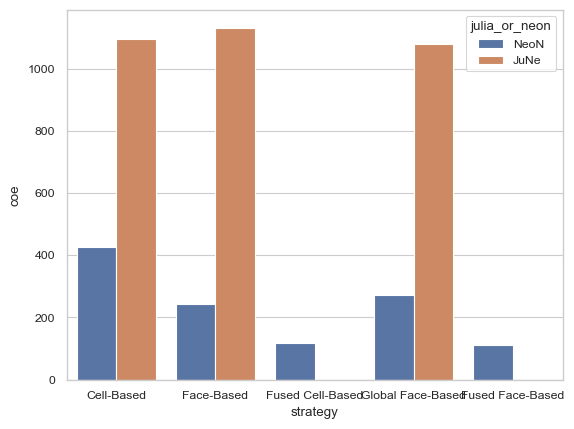

In [118]:
p= sns.barplot(
    data=neon,
    x="strategy",
    y="coe",
    hue="julia_or_neon"
)
neon[~neon["coe"].isna()]

In [119]:
def coe64(n, strat):
    ncells= 65334765
    nops = ncells / (n/1000)
    iops = ncells / (0.880597202*1000)
    coe = nops/(iops/64)
    print(f"{strat:30}: coe = {coe}")

In [120]:
neon["merged"] = neon["julia_or_neon"] +", " + neon["strategy"]

In [121]:
strats = neon["merged"].unique()
for strat in strats:
    sdf = neon[neon["merged"]==strat]["time_us"].mean()
    coe64(sdf, strat)


NeoN, Cell-Based              : coe = 426.9497502159058
NeoN, Face-Based              : coe = 242.28007070880764
NeoN, Fused Cell-Based        : coe = 117.18420692938992
NeoN, Global Face-Based       : coe = 273.3898350101384
JuNe, Face-Based              : coe = 1134.1964364660898
JuNe, Cell-Based              : coe = 1096.8475522167296
JuNe, Global Face-Based       : coe = 1081.295848659849
NeoN, Fused Face-Based        : coe = 112.65808496798658
